In [ ]:
#@title

!pip install selenium
!apt-get update # to update ubuntu to correctly run apt install
!apt install chromium-chromedriver
!cp /usr/lib/chromium-browser/chromedriver /usr/bin
!pip install pandas


Hit:1 https://cloud.r-project.org/bin/linux/ubuntu bionic-cran35/ InRelease
Ign:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  InRelease
Ign:3 https://developer.download.nvidia.com/compute/machine-learning/repos/ubuntu1804/x86_64  InRelease
Hit:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  Release
Hit:5 https://developer.download.nvidia.com/compute/machine-learning/repos/ubuntu1804/x86_64  Release
Hit:6 http://archive.ubuntu.com/ubuntu bionic InRelease
Hit:7 http://ppa.launchpad.net/graphics-drivers/ppa/ubuntu bionic InRelease
Get:8 http://security.ubuntu.com/ubuntu bionic-security InRelease [88.7 kB]
Get:10 http://archive.ubuntu.com/ubuntu bionic-updates InRelease [88.7 kB]
Hit:12 http://ppa.launchpad.net/marutter/c2d4u3.5/ubuntu bionic InRelease
Get:13 http://archive.ubuntu.com/ubuntu bionic-backports InRelease [74.6 kB]
Get:14 http://archive.ubuntu.com/ubuntu bionic-updates/main amd64 Packages [1,271 kB]
Get:15 http://ar

In [ ]:
'''
!pip install numpy
!pip install pandas
!pip install pandas_datareader
!pip install mpl_finance
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
!tar -xzvf ta-lib-0.4.0-src.tar.gz
%cd ta-lib
!./configure --prefix=/usr
!make
!make install
!pip install Ta-Lib
# basic
import numpy as np
import pandas as pd

# get data
import pandas_datareader as pdr

# visual
import matplotlib.pyplot as plt
import mpl_finance as mpf

%matplotlib inline
import seaborn as sns

#time
import datetime as datetime

#talib
import talib
'''

'\n!pip install numpy\n!pip install pandas\n!pip install pandas_datareader\n!pip install mpl_finance\n!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz\n!tar -xzvf ta-lib-0.4.0-src.tar.gz\n%cd ta-lib\n!./configure --prefix=/usr\n!make\n!make install\n!pip install Ta-Lib\n# basic\nimport numpy as np\nimport pandas as pd\n\n# get data\nimport pandas_datareader as pdr\n\n# visual\nimport matplotlib.pyplot as plt\nimport mpl_finance as mpf\n\n%matplotlib inline\nimport seaborn as sns\n\n#time\nimport datetime as datetime\n\n#talib\nimport talib\n'

In [ ]:
'''
start = datetime.datetime(2020,1,1)
df_2330 = pdr.DataReader('8069.TWO', 'yahoo', start=start)
df_2330
'''

"\nstart = datetime.datetime(2020,1,1)\ndf_2330 = pdr.DataReader('8069.TWO', 'yahoo', start=start)\ndf_2330\n"

scrawler for stock value

In [ ]:
#@title

import sys
from selenium import webdriver
chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument('--headless')
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--disable-dev-shm-usage')
wd = webdriver.Chrome('chromedriver',options=chrome_options)
driver =webdriver.Chrome('chromedriver',options=chrome_options)
stock_code=input("請輸入股票代號:")
#stock_code = '2885'
driver.get('https://goodinfo.tw/StockInfo/ShowK_Chart.asp?STOCK_ID='+stock_code+'&CHT_CAT2=DATE')
#stock_code = driver.find_element_by_id('txtStockCode')
#stock_code
#stock_code.send_keys('元太')
#from selenium.webdriver.common.keys import Keys
#stock_code.send_keys(Keys.RETURN)
q = driver.find_element_by_css_selector('td > input:nth-child(5)')
print(q)
from selenium.webdriver.common.keys import Keys
q.send_keys(Keys.RETURN)


請輸入股票代號:8069
<selenium.webdriver.remote.webelement.WebElement (session="a2d9bb1b5191d83759fc9ee34936c8a8", element="542288fe-1bfa-4b2d-8260-f975b54b5b01")>


In [ ]:
#@title

import pandas as pd
df_list = pd.read_html('K_Chart.xls')
df = pd.DataFrame(df_list[0])
the_last_one = len(df)
df.drop([the_last_one-2,the_last_one-1],axis=0,inplace=True)#刪除前兩行空值
print(df)
df_s=df.sort_index(axis=0,ascending=False)
print(df_s)

       0      1      2      3      4   ...      17     18    19    20    21
0   07/01   40.9   42.3  40.85  41.95  ...     NaN    NaN   NaN   NaN   NaN
1   06/30  41.05  41.15  40.55   40.6  ...    +241  25333    -3  2396   9.5
2   06/29   40.5  41.25   40.2  40.65  ...    -734  25092   -25  2399   9.6
3   06/24  40.95     41   40.3   40.5  ...    -345  25826   -94  2424   9.4
4   06/23  41.15  41.25   40.5  40.65  ...    -325  26171   -30  2518   9.6
5   06/22  40.25   41.2  40.25  40.55  ...    -948  26496  +172  2548   9.6
6   06/19  41.35  41.45  40.35   40.5  ...   -1336  27444  -114  2376   8.7
7   06/18  39.05   40.6   38.7   40.6  ...   -1482  28780  +304  2490   8.7
8   06/17  38.65   38.8     38   38.4  ...  +1,708  30262   +42  2186   7.2
9   06/16   38.2  38.85   37.8  38.75  ...  +1,058  28554    -1  2144   7.5
10  06/15   38.1  38.35   37.5   37.7  ...     -91  27496   -36  2145   7.8
11  06/12   37.3  38.45   37.3  37.95  ...    -312  27587  -309  2181   7.9
12  06/11   

### 先以Excel開啟檔案

In [ ]:
#@title
'''
import pandas as pd
import math
df = pd.read_excel(r'/content/PIP_test.xlsx',sheet_name="K_Chart")
print(df)
df.drop([0,1],axis=0,inplace=True)#刪除前兩行空值
'''
df_tmp = df_s
#rename column
df_tmp.columns = ['交易日期', '開盤', '最高', '最低', '收盤', '漲跌', '漲跌(%)', '振幅(%)', '成交張數', '成交筆數', '成交均張', '成交億元', '外資張數', '投信張數', '自營商張數', '合計張數', '外資持股(%)', '融資增減(張)', '融資餘額(張)', '融券增減(張)', '融券餘額(張)', '資券比(%)']
df_format = df_tmp
print(df_format)
print(df_format.iloc[:,4])
print(df_format['交易日期'])
df_stockvalue=df_format.iloc[:,4].reset_index().drop(['index'], axis=1)
#print(df_stockvalue)
#根据行索引和列索引获取元素值
idx=0
num1=df_stockvalue.iat[idx,0]
print (num1)
#獲取樣本資料個數
length_of_data=len(df_stockvalue)
print(length_of_data)

     交易日期     開盤     最高     最低     收盤  ... 融資增減(張) 融資餘額(張) 融券增減(張) 融券餘額(張) 資券比(%)
59  04/06   25.3  25.35   24.8   25.2  ...    -123   15681    -104     447    2.9
58  04/07   25.8  25.95  25.55   25.9  ...    +243   15924    -117     330    2.1
57  04/08     26  26.95  25.85   26.8  ...     +84   16008    -109     221    1.4
56  04/09  27.45   28.4   27.4   27.6  ...     +78   16086      -4     217    1.3
55  04/10   27.8   28.1   27.6   27.8  ...    -139   15947    -217       0      0
54  04/13   27.8   27.9   27.5   27.5  ...     -25   15922       0       0      0
53  04/14   27.8  27.95   27.7   27.9  ...     +55   15977       0       0      0
52  04/15   28.2   28.4     28  28.15  ...    -327   15650       0       0      0
51  04/16  28.05   29.4   27.9   29.1  ...     -78   15572     +68      68    0.4
50  04/17   29.9   30.2  28.75  28.75  ...    +565   16137     +58     126    0.8
49  04/20     29   29.1   28.7  28.85  ...     +44   16181     +21     147    0.9
48  04/21  28.85



```
# Standardize the input data
```



In [ ]:
#@title

from sklearn.preprocessing import StandardScaler
df_stockvalue_standard = df_stockvalue
df_stockvalue_standard=StandardScaler().fit_transform(df_stockvalue_standard).flatten()
print(df_stockvalue)
print(df_stockvalue_standard)



       收盤
0    25.2
1    25.9
2    26.8
3    27.6
4    27.8
5    27.5
6    27.9
7   28.15
8    29.1
9   28.75
10  28.85
11   27.8
12   28.1
13  28.35
14  28.95
15   30.8
16  30.95
17  30.75
18     31
19  30.55
20   30.6
21  31.25
22  31.95
23     33
24   34.9
25  35.85
26  37.45
27   36.5
28   35.8
29   36.1
30   36.3
31  39.05
32  38.85
33   39.8
34   42.3
35   41.7
36   41.6
37  40.55
38   40.6
39  41.85
40     41
41   41.1
42  40.35
43   40.8
44  40.55
45  37.35
46  38.05
47   38.2
48  37.95
49   37.7
50  38.75
51   38.4
52   40.6
53   40.5
54  40.55
55  40.65
56   40.5
57  40.65
58   40.6
59  41.95
[-1.85642523 -1.72669169 -1.55989142 -1.41162451 -1.37455778 -1.43015787
 -1.35602442 -1.30969101 -1.13362406 -1.19849083 -1.17995747 -1.37455778
 -1.31895769 -1.27262428 -1.1614241  -0.81855688 -0.79075684 -0.82782356
 -0.78149016 -0.86489029 -0.85562361 -0.73515675 -0.6054232  -0.41082289
 -0.05868898  0.11737797  0.41391178  0.23784483  0.10811129  0.16371138
  0.2007781   0.7104456  

```
# This function is made for return stock value according to index
```



In [ ]:
#@title
def stock_value_of_index(index):
  stock_value=df_stockvalue.iat[index,0]
  #stock_value=df_stockvalue[index]#for standardize data input
  return stock_value

In [ ]:
#@title
def stock_value_standard_of_index(index):
  #stock_value=df_stockvalue.iat[index,0]
  stock_value_standard=df_stockvalue_standard[index]#for standardize data input
  return stock_value_standard

```
# This function is for index to x value
```



In [ ]:
#@title
def x_value_of_index(index):
  print("index="+str(index))
  x_value=index+1
  print("x_value="+str(x_value))
  return x_value

定義全域變數, 初始list

```
PIP_BY_ORDER:PIP依加入順序
PIP_MSE:PIP MSE(依加入順序）
```

In [ ]:
#@title
PIP_H=0
PIP_E=int(length_of_data)-1
PIP_INDEX_BY_ORDER=[]
PIP_VD_SUM=[]
PIP_VD_MVRANGE=[]
PIP_VD_MVRANGE.append(0)
PIP_VD_MVRANGE.append(0)
#print(df_stockvalue.iat[PIP_E,0])
#initial PIP_INDEX_BY_ORDER
PIP_INDEX_BY_ORDER.append(PIP_H)
PIP_INDEX_BY_ORDER.append(PIP_E)
PIP_INDEX_BY_ORDER
BEST_PIP_INDEX=[]
BEST_PIP_X=[]
BEST_PIP_Y=[]
ORI_PIP_Y=[]

PIP_VD: 
```
VD(p3,pc)=|yc-y3|=|(y1+(y2-y1)*[(xc-x1)/(x2-x1)])-y3| =([(xc-x1)/(x2-x1)]*(y2-y1)+y1)-y3
input:  pip_start, pip_end, pip_candidate
output: pip_vd
VD記得取絕對值
```

In [ ]:
#@title
def pip_vd( pip_start_x, pip_start_y, pip_end_x, pip_end_y, pip_candidate_x, pip_candidate_y ):
  #針對index 0~59, 加1後為該數列的x值
  '''
  print(pip_start_x)
  print(pip_end_x)
  print(pip_candidate_x)
  print(pip_start_y)
  print(pip_end_y)
  print(pip_candidate_y)
  '''
  pip_start_x=float(pip_start_x)
  pip_end_x=float(pip_end_x)
  pip_candidate_x=float(pip_candidate_x)
  pip_start_y=float(pip_start_y)
  pip_end_y=float(pip_end_y)
  pip_candidate_y=float(pip_candidate_y)
  print(pip_start_x, pip_start_y)
  print(pip_end_x, pip_end_y)
  print(pip_candidate_x, pip_candidate_y)
  # Add both the parameters and return them."
  vd = (((pip_candidate_x-pip_start_x)/(pip_end_x-pip_start_x))*(pip_end_y-pip_start_y)+pip_start_y)-pip_candidate_y
  vd = round((vd),3)
  vd = vd**(2)
  vd = vd**(0.5)
  return vd

以MSE決定PIP數目
```
# MSE between after PIP and Original
# 直接利用VD平方後取平均為MSE
```



In [ ]:
#@title
def pip_num_by_mse():
  pip_num=0
  for i in range(0,length_of_data-3,1):
    print(PIP_VD_SUM[i],PIP_VD_SUM[i+1])
    pip_vd_mvrange = ((PIP_VD_SUM[i] - PIP_VD_SUM[i + 1])**(2))**(0.5)
    PIP_VD_MVRANGE.append(pip_vd_mvrange)
#  for j in range(length_of_data-3,0,-1):
#    sum += PIP_VD_MVRANGE[i]
  print("PIP_VD_MVRANGE="+str(PIP_VD_MVRANGE))
  sum_tmp=sum(PIP_VD_MVRANGE)
  MRAVG = sum_tmp / (length_of_data - 2)
  print("MRAVG="+str(MRAVG))
  for k in range(2,length_of_data-1,1):
    print("K="+str(k)+"PIP_VD_MVRANGE[k]="+str(PIP_VD_MVRANGE[k]))
    if PIP_VD_MVRANGE[k] > MRAVG:
      pip_num = k + 1
      pip_num += 1 #這裡+1是取第一個超過平均值的下一點為PIP數目點
  return pip_num

用來更新PIP_Head and PIP_End 




In [ ]:
#@title
def pip_update_phpe( ph, pe, pip_num, mintmp ):
  global PIP_H, PIP_E
  print("###pip_update_phpe###")
  print(ph, pe, pip_num, mintmp)
  PIP_H=mintmp
  mintmp=length_of_data
  for i in range(0,pip_num):
    if PIP_INDEX_BY_ORDER[i] > PIP_H and PIP_INDEX_BY_ORDER[i] < mintmp:
      mintmp=PIP_INDEX_BY_ORDER[i]
  PIP_E=mintmp
  print(PIP_H, PIP_E)
  return mintmp



```
# PIP main function start here
```



In [ ]:
#@title
'''
PIP_H=1
pip_candidate=22
print(PIP_H, PIP_E)
vd=pip_vd(x_value_of_index(PIP_H),stock_value_of_index(PIP_H),x_value_of_index(PIP_E),stock_value_of_index(PIP_E),x_value_of_index(pip_candidate),stock_value_of_index(pip_candidate))
print(vd)
PIP_H=43
pip_update_phpe(PIP_H,PIP_E,33)
print("now="+str(PIP_H))
print("now1="+str(PIP_E))
'''
'''
max_vd = 0
pip_candidate = 0
vd_sum = 0
for idx in range(length_of_data):
  if idx !=PIP_H or idx !=PIP_E:
    tmp_vd=pip_vd(x_value_of_index(PIP_H),stock_value_of_index(PIP_H),x_value_of_index(PIP_E),stock_value_of_index(PIP_E),x_value_of_index(idx),stock_value_of_index(idx))
    print(tmp_vd)
    vd_sum+=tmp_vd
    if tmp_vd > max_vd:
      max_vd=tmp_vd
      pip_candidate=idx
PIP_VD_SUM.append(vd_sum)
PIP_INDEX_BY_ORDER.append(pip_candidate)
print ("MAX_VD="+str(max_vd))
print (PIP_INDEX_BY_ORDER)
print(PIP_VD_SUM)
'''
pip_num=len(PIP_INDEX_BY_ORDER)
while pip_num < length_of_data:
  mintmp = 0 #為了選出ph, pe
  print(PIP_INDEX_BY_ORDER)
  max_vd = 0
  pip_candidate = 0
  vd_sum = 0
  print("len of PIP_INDEX_BY_ORDER="+str(len(PIP_INDEX_BY_ORDER)))
  for i in range(1, pip_num):
    if len(PIP_INDEX_BY_ORDER) > 2:
      print("i="+str(i)+", pip_update_phpe")
      mintmp=pip_update_phpe(PIP_H, PIP_E, pip_num, mintmp)
    else:
      mintmp=1
    print ("pip_num="+str(pip_num))
    print("mintmp="+str(mintmp))

    for j in range(int(PIP_H+1), int(PIP_E)):
      print ("j="+str(j))
      #if j !=PIP_H or j !=PIP_E:
      print("PIP_H="+str(PIP_H)+", PIP_E="+str(PIP_E))
      tmp_vd=pip_vd(x_value_of_index(PIP_H),stock_value_standard_of_index(PIP_H),x_value_of_index(PIP_E),stock_value_standard_of_index(PIP_E),x_value_of_index(j),stock_value_standard_of_index(j))
      print("round:"+str(j)+"tmp_vd="+str(tmp_vd))
      vd_sum+=tmp_vd
      if tmp_vd > max_vd:
        max_vd=tmp_vd
        pip_candidate=j
        print("j="+str(j)+", pip_candidate="+str(pip_candidate))
  PIP_VD_SUM.append(vd_sum)
  print("!!!!pip_can="+str(pip_candidate))
  PIP_INDEX_BY_ORDER.append(pip_candidate)
  print("max_vd="+str(max_vd))
  print("pip_candidate="+str(pip_candidate))
  pip_num+=1
print("Final PIP:"+str(PIP_INDEX_BY_ORDER))
print("Final PIP VD SUM="+str(PIP_VD_SUM))
print("length of VD SUM="+str(len(PIP_VD_SUM)))
best_pip_num=pip_num_by_mse()
print("best_pip_num="+str(best_pip_num))

Streaming output truncated to the last 5000 lines.
mintmp=51
i=44, pip_update_phpe
###pip_update_phpe###
50 51 47 51
51 52
pip_num=47
mintmp=52
i=45, pip_update_phpe
###pip_update_phpe###
51 52 47 52
52 58
pip_num=47
mintmp=58
j=53
PIP_H=52, PIP_E=58
index=52
x_value=53
index=58
x_value=59
index=53
x_value=54
53.0 0.9977127281707225
59.0 0.9977127281707225
54.0 0.9791793647991298
round:53tmp_vd=0.019
j=54
PIP_H=52, PIP_E=58
index=52
x_value=53
index=58
x_value=59
index=54
x_value=55
53.0 0.9977127281707225
59.0 0.9977127281707225
55.0 0.9884460464849255
round:54tmp_vd=0.009
j=55
PIP_H=52, PIP_E=58
index=52
x_value=53
index=58
x_value=59
index=55
x_value=56
53.0 0.9977127281707225
59.0 0.9977127281707225
56.0 1.0069794098565181
round:55tmp_vd=0.009
j=56
PIP_H=52, PIP_E=58
index=52
x_value=53
index=58
x_value=59
index=56
x_value=57
53.0 0.9977127281707225
59.0 0.9977127281707225
57.0 0.9791793647991298
round:56tmp_vd=0.019
j=57
PIP_H=52, PIP_E=58
index=52
x_value=53
index=58
x_value=59
i



```
# This is quick sort algrithm
```



In [ ]:
#@title
# This function takes last element as pivot, places 
# the pivot element at its correct position in sorted 
# array, and places all smaller (smaller than pivot) 
# to left of pivot and all greater elements to right 
# of pivot 
def partition(arr,low,high): 
    i = ( low-1 )         # index of smaller element 
    pivot = arr[high]     # pivot 
  
    for j in range(low , high): 
  
        # If current element is smaller than or 
        # equal to pivot 
        if   arr[j] <= pivot: 
          
            # increment index of smaller element 
            i = i+1 
            arr[i],arr[j] = arr[j],arr[i] 
  
    arr[i+1],arr[high] = arr[high],arr[i+1] 
    return ( i+1 ) 

In [ ]:
#@title
def quickSort(arr,low,high): 
    if low < high: 
  
        # pi is partitioning index, arr[p] is now 
        # at right place 
        pi = partition(arr,low,high) 
  
        # Separately sort elements before 
        # partition and after partition 
        quickSort(arr, low, pi-1) 
        quickSort(arr, pi+1, high)



```
# This is to process the BEST_PIP_X and BEST_PIP_Y as plot input
```



In [ ]:
#@title
print("best_pip_num="+str(best_pip_num))

for i in range(0,best_pip_num):
  print(PIP_INDEX_BY_ORDER[i])
  BEST_PIP_INDEX.append(PIP_INDEX_BY_ORDER[i])
print("length of BEST_PIP_INDEX="+str(len(BEST_PIP_INDEX)))
BEST_PIP_X=BEST_PIP_INDEX
quickSort(BEST_PIP_INDEX,0,len(BEST_PIP_INDEX)-1)
print(BEST_PIP_X)
for j in range(0,len(BEST_PIP_X)):
  print("BEST_PIP_Y="+str(stock_value_standard_of_index(BEST_PIP_X[j])))
  BEST_PIP_Y.append(stock_value_standard_of_index(BEST_PIP_X[j]))
  print("ORI_PIP_Y="+str(stock_value_of_index(BEST_PIP_X[j])))
  
  ORI_PIP_Y.append(float(stock_value_of_index(BEST_PIP_X[j])))
print(BEST_PIP_Y)

best_pip_num=22
0
59
34
45
20
44
30
26
8
11
15
31
33
37
39
14
28
23
58
52
51
3
length of BEST_PIP_INDEX=22
[0, 3, 8, 11, 14, 15, 20, 23, 26, 28, 30, 31, 33, 34, 37, 39, 44, 45, 51, 52, 58, 59]
BEST_PIP_Y=-1.8564252310545029
ORI_PIP_Y=25.2
BEST_PIP_Y=-1.4116245101362856
ORI_PIP_Y=27.6
BEST_PIP_Y=-1.1336240595624
ORI_PIP_Y=29.1
BEST_PIP_Y=-1.374557783393101
ORI_PIP_Y=27.8
BEST_PIP_Y=-1.161424104619789
ORI_PIP_Y=28.95
BEST_PIP_Y=-0.8185568822453299
ORI_PIP_Y=30.8
BEST_PIP_Y=-0.8556236089885145
ORI_PIP_Y=30.6
BEST_PIP_Y=-0.4108228880702979
ORI_PIP_Y=33
BEST_PIP_Y=0.4139117819655631
ORI_PIP_Y=37.45
BEST_PIP_Y=0.10811128633428795
ORI_PIP_Y=35.8
BEST_PIP_Y=0.20077810319224978
ORI_PIP_Y=36.3
BEST_PIP_Y=0.71044559591104
ORI_PIP_Y=39.05
BEST_PIP_Y=0.8494458211979827
ORI_PIP_Y=39.8
BEST_PIP_Y=1.312779905487792
ORI_PIP_Y=42.3
BEST_PIP_Y=0.9884460464849255
ORI_PIP_Y=40.55
BEST_PIP_Y=1.229379770315627
ORI_PIP_Y=41.85
BEST_PIP_Y=0.9884460464849255
ORI_PIP_Y=40.55
BEST_PIP_Y=0.3953784185939705
ORI_PIP

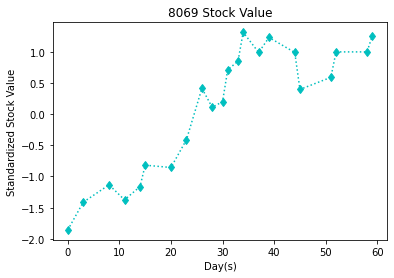

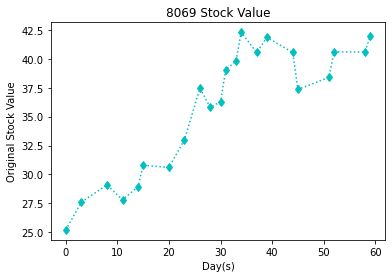

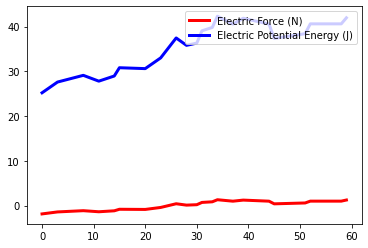

[0, 59, 34, 45, 20, 44, 30, 26, 8, 11, 15, 31, 33, 37, 39, 14, 28, 23, 58, 52, 51, 3, 42, 5, 10, 38, 32, 46, 49, 50, 36, 7, 24, 40, 41, 43, 25, 18, 47, 4, 19, 22, 35, 9, 13, 17, 16, 27, 1, 53, 55, 56, 57, 6, 2, 29, 12, 21, 54, 0]


In [ ]:
#@title
import matplotlib.pyplot as plt
plt.plot(BEST_PIP_X,BEST_PIP_Y,'c:d')
plt.xlabel("Day(s)")
plt.ylabel("Standardized Stock Value")
plt.title(stock_code+" Stock Value")
plt.show()
plt.plot(BEST_PIP_X,ORI_PIP_Y,'c:d')
plt.xlabel("Day(s)")
plt.ylabel("Original Stock Value")
plt.title(stock_code+" Stock Value")
plt.show()
line1, = plt.plot(BEST_PIP_X, BEST_PIP_Y, color = 'red', linewidth = 3, label = 'Electric Force (N)')             
line2, = plt.plot(BEST_PIP_X, ORI_PIP_Y, color = 'blue', linewidth = 3, label = 'Electric Potential Energy (J)')
plt.legend(handles = [line1, line2], loc='upper right')
plt.show()
print(PIP_INDEX_BY_ORDER)